In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Cloud Warehouse Compersion Chart.csv', encoding='unicode_escape')

# Clean karo
df.columns = ['index', 'Service', 'Shiprocket_Price', 'INCREFF_Price']
df = df.drop(columns=['index'])
df = df.drop(index=0).reset_index(drop=True)

df['Shiprocket_Price'] = pd.to_numeric(df['Shiprocket_Price'], errors='coerce')
df['INCREFF_Price'] = pd.to_numeric(df['INCREFF_Price'], errors='coerce')
df = df.dropna()

print(df)

Empty DataFrame
Columns: [Service, Shiprocket_Price, INCREFF_Price]
Index: []


In [2]:
df_raw = pd.read_csv('../data/Cloud Warehouse Compersion Chart.csv', encoding='unicode_escape')
print(df_raw)

    index                                         Shiprocket  \
0       0                                              Heads   
1       1                      Inbound (Fresh Stock and RTO)   
2       2                                           Outbound   
3       3                                    Storage Fee/Cft   
4       4                   Customer Return with Detailed QC   
5       5  (A) SCOPE OF WORK and STANDARD OPERATING PROCE...   
6       6                                             Inward   
7       7                                                NaN   
8       8                                                NaN   
9       9                                                NaN   
10     10                                                NaN   
11     11                                                NaN   
12     12                                            Outward   
13     13                                                NaN   
14     14                               

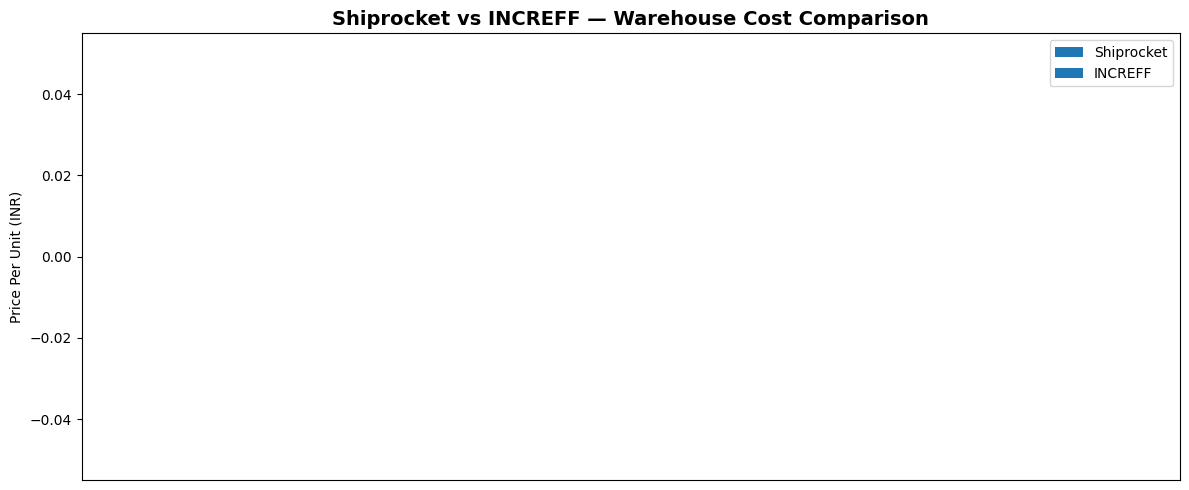

In [3]:
x = range(len(df))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - 0.2 for i in x], df['Shiprocket_Price'], width=0.4, label='Shiprocket', color='#FF9900')
ax.bar([i + 0.2 for i in x], df['INCREFF_Price'], width=0.4, label='INCREFF', color='#2874F0')

ax.set_xticks(list(x))
ax.set_xticklabels(df['Service'], rotation=45, ha='right')
ax.set_title('Shiprocket vs INCREFF — Warehouse Cost Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Price Per Unit (INR)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/chart_warehouse.png', dpi=150)
plt.show()

In [4]:
print("=== Warehouse Comparison Summary ===\n")
print(f"Shiprocket Avg Cost: ₹{df['Shiprocket_Price'].mean():.2f}")
print(f"INCREFF Avg Cost: ₹{df['INCREFF_Price'].mean():.2f}")
cheaper = "Shiprocket" if df['Shiprocket_Price'].mean() < df['INCREFF_Price'].mean() else "INCREFF"
print(f"Cheaper Option: {cheaper}")

=== Warehouse Comparison Summary ===

Shiprocket Avg Cost: ₹nan
INCREFF Avg Cost: ₹nan
Cheaper Option: INCREFF
